<a href="https://colab.research.google.com/github/JFcamp/rag-plantas-medicinais/blob/main/rag_plantas_medicinais_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌿 Identificador de Plantas Medicinais + RAG

Tire uma foto de uma planta (ou pegue uma imagem no Google), a IA identifica qual é e você pergunta: **para que serve, como fazer o chá, qual a dose, quem não pode usar, como cultivar**...

1. **Dataset com fotos reais**: o notebook baixa ~300 fotos por planta do **iNaturalist** (fotos de pessoas do mundo todo, identificadas por especialistas, com licenças abertas).
2. **Classificador de imagens**: uma EfficientNet-B0 é treinada (fine-tuning) para reconhecer **14 plantas medicinais**.
3. **RAG**: o `guia_plantas_medicinais.pdf` (43 páginas, com indicações e doses do **Formulário de Fitoterápicos da ANVISA**) é indexado, e o modelo **Qwen2.5-3B-Instruct** responde usando **somente** o conteúdo do guia, citando as páginas.

```
foto ──► EfficientNet ──► "Boldo-brasileiro (94%)"
                               │
pergunta ──► "(Planta: Boldo-brasileiro) pergunta" ──► busca no PDF (e5 + FAISS) ──► Qwen ──► resposta + página
```

**As 14 plantas:** alecrim · babosa · boldo-brasileiro · calêndula · camomila · capim-limão · erva-cidreira-brasileira (lípia) · espinheira-santa · gengibre · hortelã · manjericão · melissa · tanchagem · vinagreira (hibisco).

> ⚠️ **Projeto educativo.** A identificação por IA pode errar, e as informações não substituem a orientação de médicos, farmacêuticos e outros profissionais de saúde. Nunca use uma planta com base apenas na identificação feita por IA.

### ⚙️ Antes de começar
- **Ambiente de execução → Alterar o tipo de ambiente de execução → T4 GPU**.
- Tenha em mãos o PDF `guia_plantas_medicinais.pdf`.
- Rode as células **em ordem**. A primeira execução completa leva cerca de 15 a 20 minutos (a maior parte é o download das fotos).

---
## Parte 0 · Preparação do ambiente

In [ ]:
# 1 · Instalação das bibliotecas e verificação da GPU
!pip install -q -U transformers accelerate sentence-transformers faiss-cpu pypdf

import torch
assert torch.cuda.is_available(), "⚠️ GPU não encontrada: Ambiente de execução → Alterar o tipo → T4 GPU"
print("GPU:", torch.cuda.get_device_name(0))
print("Memória: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 17.5 MB/s eta 0:00:00
GPU: Tesla T4
Memória: 15.6 GB


In [ ]:
# 2 · Configurações do projeto (ajuste aqui, se quiser)
device = "cuda"

# --- Dataset (iNaturalist) ---
# pasta: (nome em português, id do táxon no iNaturalist)
ESPECIES = {
    "alecrim":              ("Alecrim", 636795),
    "babosa":               ("Babosa", 126882),
    "boldo":                ("Boldo-brasileiro", 157127),
    "calendula":            ("Calêndula", 75931),
    "camomila":             ("Camomila", 77965),
    "capim_limao":          ("Capim-limão", 123728),
    "erva_cidreira_lippia": ("Erva-cidreira-brasileira (lípia)", 223926),
    "espinheira_santa":     ("Espinheira-santa", 431288),
    "gengibre":             ("Gengibre", 122971),
    "hortela":              ("Hortelã", 54570),
    "manjericao":           ("Manjericão", 61398),
    "melissa":              ("Melissa (erva-cidreira)", 59901),
    "tanchagem":            ("Tanchagem", 58961),
    "vinagreira":           ("Vinagreira (hibisco)", 1687652),
}
FOTOS_POR_ESPECIE = 300
PASTA_DATASET = "dataset_plantas"
LICENCAS = ["cc0", "cc-by", "cc-by-nc"]    # só fotos com licença aberta

# --- Classificador de imagens ---
MODELO_IMG_PATH = "modelo_plantas.pt"
IMG_SIZE = 224
BATCH = 32
EPOCAS = 10
LIMIAR_CONFIANCA = 0.50          # abaixo disso, o modelo diz que não tem certeza

# --- RAG ---
EMBEDDER_ID = "intfloat/multilingual-e5-base"
LLM_ID = "Qwen/Qwen2.5-3B-Instruct"
CHUNK_TAMANHO, CHUNK_SOBREPOSICAO = 800, 150
TOP_K_CHUNKS = 6                 # quantos trechos a busca recupera
MAX_PAGINAS = 3                  # quantas páginas inteiras vão para o modelo
MAX_NOVOS_TOKENS = 450

SYSTEM_PROMPT = (
    "Você é um assistente educativo que responde perguntas sobre plantas medicinais usando um guia. "
    "Use SOMENTE as informações dos trechos fornecidos. "
    "Se a resposta não estiver nos trechos, diga exatamente: "
    "\"Não encontrei essa informação no documento.\" "
    "Não invente dados, doses ou indicações. Quando a pergunta for sobre como usar, preparar ou a dose de uma planta, "
    "informe também as principais contraindicações que aparecem nos trechos e lembre que o uso deve ser orientado "
    "por um profissional de saúde. Responda em português, de forma direta e organizada, "
    "e indique a(s) página(s) de onde tirou a informação, no formato (pág. X)."
)
print(f"✅ Configurações carregadas: {len(ESPECIES)} plantas.")

✅ Configurações carregadas: 14 plantas.


---
## Parte 1 · Dataset com fotos reais (iNaturalist)

O [iNaturalist](https://www.inaturalist.org) é uma plataforma de ciência cidadã com milhões de fotos de plantas e animais tiradas por pessoas comuns e identificadas pela comunidade. Para cada planta, o notebook baixa primeiro as fotos com identificação confirmada (**grau pesquisa**) e, se faltar, completa com as demais. Os créditos de cada foto (autor e licença) ficam salvos em `creditos.csv`.

Por serem fotos do mundo real (no vaso, no quintal, na mão, no mercado), o modelo aprende a reconhecer as plantas também em fotos de celular e do Google.

In [ ]:
# 3 · Baixar as fotos do iNaturalist (cerca de 5 a 10 minutos)
import os, time, csv, io, requests
import concurrent.futures as cf
from PIL import Image

API = "https://api.inaturalist.org/v1/observations"
H = {"User-Agent": "minicurso-rag-plantas-medicinais/1.0 (uso educacional)"}

def chamar_api(params, tentativas=5):
    for t in range(tentativas):
        try:
            r = requests.get(API, params=params, headers=H, timeout=30)
            if r.status_code == 200:
                time.sleep(1.1)              # respeita o limite de ~1 requisição/segundo da API
                return r.json()
        except requests.RequestException:
            pass
        time.sleep(5 * (t + 1))
    raise RuntimeError("Falha ao acessar a API do iNaturalist. Tente rodar a célula de novo.")

def listar_fotos(taxon_id, alvo):
    """Uma foto por observação: primeiro grau pesquisa, depois 'precisa de ID' e 'casual'."""
    fotos, vistas = [], set()
    for grau in ("research", "needs_id", "casual"):
        id_abaixo = None
        while len(fotos) < alvo:
            p = dict(taxon_id=taxon_id, photos="true", photo_license=",".join(LICENCAS),
                     quality_grade=grau, per_page=200, order_by="id", order="desc")
            if id_abaixo:
                p["id_below"] = id_abaixo
            obs = chamar_api(p)["results"]
            if not obs:
                break
            for o in obs:
                for f in o["photos"]:
                    if (f.get("license_code") or "") in LICENCAS and f["id"] not in vistas:
                        vistas.add(f["id"])
                        fotos.append({"obs": o["id"], "foto": f["id"], "grau": grau,
                                      "url": f["url"].replace("square", "medium"),
                                      "licenca": f.get("license_code"), "autor": f.get("attribution", "")})
                        break
                if len(fotos) >= alvo:
                    break
            id_abaixo = obs[-1]["id"]
        if len(fotos) >= alvo:
            break
    return fotos

def baixar(item, pasta):
    caminho = os.path.join(pasta, f"{item['obs']}_{item['foto']}.jpg")
    if os.path.exists(caminho):
        return caminho
    for _ in range(3):
        try:
            r = requests.get(item["url"], headers=H, timeout=30)
            img = Image.open(io.BytesIO(r.content)).convert("RGB")
            img.thumbnail((512, 512))
            img.save(caminho, quality=90)
            return caminho
        except Exception:
            time.sleep(2)
    return None

os.makedirs(PASTA_DATASET, exist_ok=True)
creditos = []
for pasta_classe, (nome, taxon_id) in ESPECIES.items():
    pasta = os.path.join(PASTA_DATASET, pasta_classe)
    os.makedirs(pasta, exist_ok=True)
    fotos = listar_fotos(taxon_id, FOTOS_POR_ESPECIE)
    with cf.ThreadPoolExecutor(max_workers=8) as ex:
        caminhos = list(ex.map(lambda it: baixar(it, pasta), fotos))
    ok = 0
    for it, c in zip(fotos, caminhos):
        if c:
            ok += 1
            creditos.append({"classe": pasta_classe, "arquivo": c, "autor": it["autor"], "licenca": it["licenca"],
                             "grau": it["grau"], "observacao": f"https://www.inaturalist.org/observations/{it['obs']}"})
    graus = {g: sum(1 for it in fotos if it["grau"] == g) for g in ("research", "needs_id", "casual")}
    print(f"{nome:34s} {ok:4d} fotos  (pesquisa: {graus['research']}, sem confirmação: {graus['needs_id'] + graus['casual']})")

with open("creditos.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=creditos[0].keys()); w.writeheader(); w.writerows(creditos)
print(f"\n✅ {len(creditos)} fotos baixadas. Créditos salvos em creditos.csv")

Alecrim                             300 fotos  (pesquisa: 300, sem confirmação: 0)
Babosa                              300 fotos  (pesquisa: 300, sem confirmação: 0)
Boldo-brasileiro                    300 fotos  (pesquisa: 300, sem confirmação: 0)
Calêndula                           300 fotos  (pesquisa: 300, sem confirmação: 0)
Camomila                            300 fotos  (pesquisa: 300, sem confirmação: 0)
Capim-limão                         300 fotos  (pesquisa: 300, sem confirmação: 0)
Erva-cidreira-brasileira (lípia)    300 fotos  (pesquisa: 300, sem confirmação: 0)
Espinheira-santa                    300 fotos  (pesquisa: 300, sem confirmação: 0)
Gengibre                            300 fotos  (pesquisa: 197, sem confirmação: 103)
Hortelã                             300 fotos  (pesquisa: 300, sem confirmação: 0)
Manjericão                          300 fotos  (pesquisa: 300, sem confirmação: 0)
Melissa (erva-cidreira)             300 fotos  (pesquisa: 300, sem confirmação: 0)
Ta

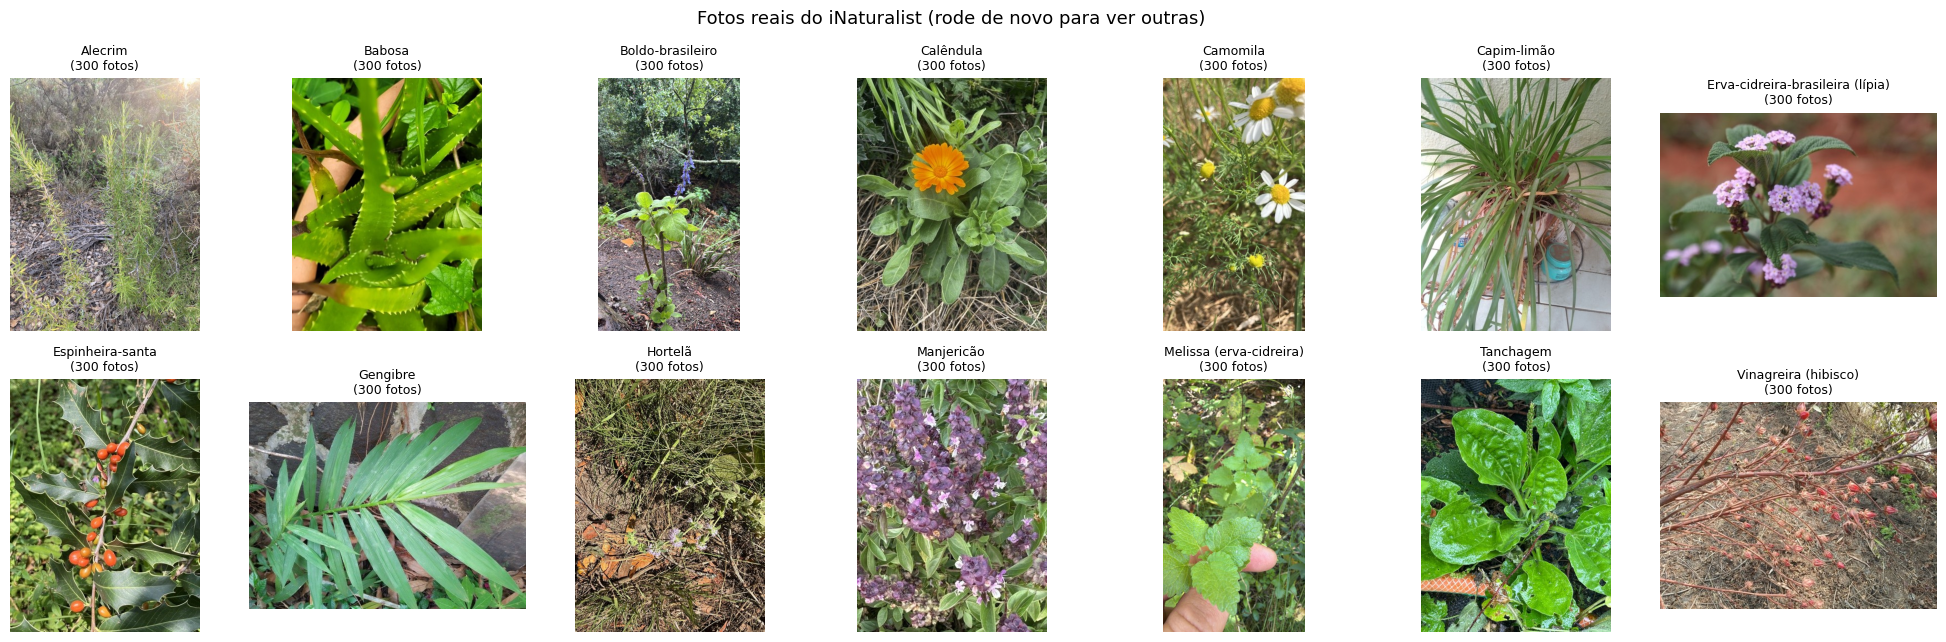

In [ ]:
# 4 · Visualizar exemplos do dataset (uma foto de cada planta)
import matplotlib.pyplot as plt
import random

classes_pastas = sorted(ESPECIES)
fig, axes = plt.subplots(2, 7, figsize=(20, 6.5))
for ax, c in zip(axes.ravel(), classes_pastas):
    arquivos = sorted(os.listdir(os.path.join(PASTA_DATASET, c)))
    ax.imshow(Image.open(os.path.join(PASTA_DATASET, c, random.choice(arquivos))))
    ax.set_title(f"{ESPECIES[c][0]}\n({len(arquivos)} fotos)", fontsize=9); ax.axis("off")
plt.suptitle("Fotos reais do iNaturalist (rode de novo para ver outras)", fontsize=13)
plt.tight_layout(); plt.show()

---
## Parte 2 · Classificador de imagens

Separamos as fotos em **treino (70%)**, **validação (15%)** e **teste (15%)**, mantendo a proporção de cada planta. A validação escolhe a melhor época; o teste, que o modelo nunca vê durante o treino, mede a acurácia final.

In [ ]:
# 5 · Preparar os dados (divisão estratificada + data augmentation)
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # normalização do ImageNet
tf_treino = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
tf_val = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

base_treino = datasets.ImageFolder(PASTA_DATASET, transform=tf_treino)
base_val    = datasets.ImageFolder(PASTA_DATASET, transform=tf_val)
CLASSES = base_treino.classes                         # nomes das pastas
NOMES = [ESPECIES[c][0] for c in CLASSES]             # nomes em português

indices = list(range(len(base_treino)))
idx_treino, idx_resto = train_test_split(indices, test_size=0.30, stratify=base_treino.targets, random_state=42)
alvos_resto = [base_treino.targets[i] for i in idx_resto]
idx_val, idx_teste = train_test_split(idx_resto, test_size=0.50, stratify=alvos_resto, random_state=42)

ds_treino, ds_val, ds_teste = Subset(base_treino, idx_treino), Subset(base_val, idx_val), Subset(base_val, idx_teste)
dl_treino = DataLoader(ds_treino, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
dl_val    = DataLoader(ds_val,    batch_size=64,    shuffle=False, num_workers=2, pin_memory=True)
dl_teste  = DataLoader(ds_teste,  batch_size=64,    shuffle=False, num_workers=2, pin_memory=True)
print(f"Treino: {len(ds_treino)} | Validação: {len(ds_val)} | Teste: {len(ds_teste)} | Classes: {len(CLASSES)}")

Treino: 2940 | Validação: 630 | Teste: 630 | Classes: 14


In [ ]:
# 6 · Treinar o modelo (fine-tuning da EfficientNet-B0) — cerca de 5 a 8 minutos na T4
import time, torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def criar_modelo():
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASSES))
    return m.to(device)

def avaliar(modelo, loader):
    modelo.eval(); acertos = total = 0
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            acertos += (modelo(x).argmax(1) == y).sum().item(); total += y.size(0)
    return acertos / total

modelo_img = criar_modelo()
criterio = nn.CrossEntropyLoss(label_smoothing=0.1)
otimizador = torch.optim.AdamW(modelo_img.parameters(), lr=3e-4, weight_decay=1e-4)
agendador = torch.optim.lr_scheduler.CosineAnnealingLR(otimizador, T_max=EPOCAS)
scaler = torch.amp.GradScaler("cuda")

melhor_acc = 0.0
for epoca in range(1, EPOCAS + 1):
    modelo_img.train(); t0 = time.time(); perda_total = 0.0
    for x, y in dl_treino:
        x, y = x.to(device), y.to(device)
        otimizador.zero_grad()
        with torch.amp.autocast("cuda"):
            perda = criterio(modelo_img(x), y)
        scaler.scale(perda).backward(); scaler.step(otimizador); scaler.update()
        perda_total += perda.item() * y.size(0)
    agendador.step()

    acc_val = avaliar(modelo_img, dl_val)
    marca = ""
    if acc_val > melhor_acc:
        melhor_acc = acc_val
        torch.save({"state_dict": modelo_img.state_dict(), "classes": CLASSES}, MODELO_IMG_PATH)
        marca = "  💾 salvo"
    print(f"Época {epoca}/{EPOCAS} | perda: {perda_total/len(ds_treino):.4f} "
          f"| acurácia validação: {acc_val:.2%} | {time.time()-t0:.0f}s{marca}")

del otimizador, scaler; torch.cuda.empty_cache()   # libera memória da GPU para o LLM
print(f"\n🏆 Melhor acurácia de validação: {melhor_acc:.2%}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s]


Época 1/10 | perda: 1.6563 | acurácia validação: 83.97% | 77s  💾 salvo
Época 2/10 | perda: 0.9593 | acurácia validação: 89.84% | 25s  💾 salvo
Época 3/10 | perda: 0.8179 | acurácia validação: 89.68% | 24s
Época 4/10 | perda: 0.7509 | acurácia validação: 91.90% | 29s  💾 salvo
Época 5/10 | perda: 0.7002 | acurácia validação: 92.06% | 29s  💾 salvo
Época 6/10 | perda: 0.6717 | acurácia validação: 91.75% | 31s
Época 7/10 | perda: 0.6530 | acurácia validação: 93.65% | 25s  💾 salvo
Época 8/10 | perda: 0.6379 | acurácia validação: 92.38% | 27s
Época 9/10 | perda: 0.6325 | acurácia validação: 93.49% | 25s
Época 10/10 | perda: 0.6324 | acurácia validação: 93.17% | 25s

🏆 Melhor acurácia de validação: 93.65%


                                  precision    recall  f1-score   support

                         Alecrim      0.955     0.933     0.944        45
                          Babosa      0.978     0.978     0.978        45
                Boldo-brasileiro      0.977     0.933     0.955        45
                       Calêndula      0.957     1.000     0.978        45
                        Camomila      1.000     0.978     0.989        45
                     Capim-limão      1.000     0.933     0.966        45
Erva-cidreira-brasileira (lípia)      0.977     0.956     0.966        45
                Espinheira-santa      0.935     0.956     0.945        45
                        Gengibre      0.837     0.911     0.872        45
                         Hortelã      0.921     0.778     0.843        45
                      Manjericão      0.800     0.889     0.842        45
         Melissa (erva-cidreira)      0.860     0.956     0.905        45
                       Tanchagem     

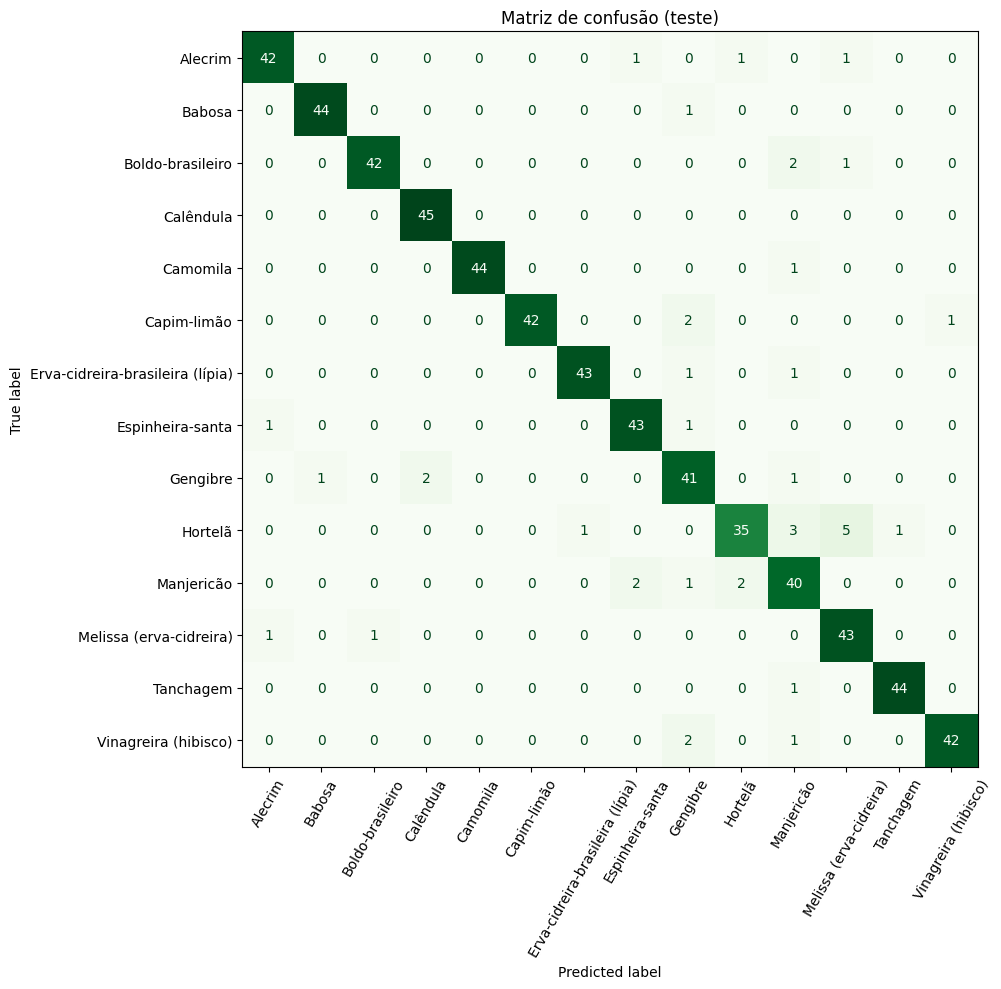

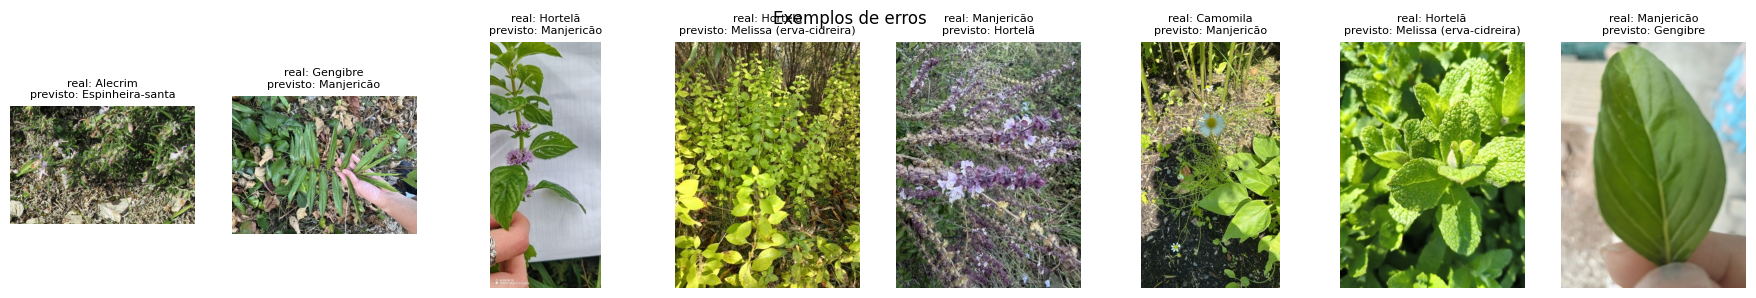

In [ ]:
# 7 · Avaliar no conjunto de TESTE: relatório por planta, matriz de confusão e exemplos de erros
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

ckpt = torch.load(MODELO_IMG_PATH, map_location=device)
modelo_img.load_state_dict(ckpt["state_dict"]); modelo_img.eval()

y_true, y_pred = [], []
with torch.no_grad(), torch.amp.autocast("cuda"):
    for x, y in dl_teste:
        y_pred += modelo_img(x.to(device)).argmax(1).cpu().tolist()
        y_true += y.tolist()

print(classification_report(y_true, y_pred, target_names=NOMES, digits=3))
fig, ax = plt.subplots(figsize=(11, 10))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=NOMES, cmap="Greens",
                                        xticks_rotation=60, ax=ax, colorbar=False)
plt.title("Matriz de confusão (teste)"); plt.tight_layout(); plt.show()

erros = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p][:8]
if erros:
    fig, axes = plt.subplots(1, len(erros), figsize=(2.8 * len(erros), 3.2))
    for ax, i in zip(np.atleast_1d(axes), erros):
        ax.imshow(Image.open(base_val.samples[idx_teste[i]][0])); ax.axis("off")
        ax.set_title(f"real: {NOMES[y_true[i]]}\nprevisto: {NOMES[y_pred[i]]}", fontsize=8)
    plt.suptitle("Exemplos de erros"); plt.show()

---
## Parte 3 · RAG sobre o Guia Completo de Plantas Medicinais

1. O texto do PDF é extraído página por página e dividido em trechos (*chunks*) de ~800 caracteres.
2. Cada trecho vira um vetor com o **multilingual-e5-base** e vai para um índice **FAISS**.
3. A busca encontra os trechos mais parecidos com a pergunta, e o modelo recebe as **páginas inteiras** de onde eles vieram. O cabeçalho de cada página do guia traz o nome da planta, o que mantém o contexto.
4. O **Qwen2.5-3B-Instruct** responde usando somente essas páginas e cita a fonte.

In [ ]:
# 8 · Carregar os modelos de texto (embeddings + LLM) — cerca de 2 minutos na primeira vez
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

embedder = SentenceTransformer(EMBEDDER_ID, device=device)
tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
llm = AutoModelForCausalLM.from_pretrained(LLM_ID, dtype=torch.float16, device_map=device)
llm.eval()
print(f"✅ Modelos carregados. Memória GPU em uso: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Modelos carregados. Memória GPU em uso: 7.4 GB


In [ ]:
# 9 · Funções do RAG: chunking, indexação, busca e resposta em tempo real (streaming)
import re, faiss
from pypdf import PdfReader
from transformers import TextIteratorStreamer
from threading import Thread

def dividir_em_chunks(texto, tamanho=CHUNK_TAMANHO, sobreposicao=CHUNK_SOBREPOSICAO):
    chunks, inicio = [], 0
    while inicio < len(texto):
        fim = min(inicio + tamanho, len(texto))
        if fim < len(texto):   # evita cortar palavras ao meio
            corte = max(texto.rfind(" ", inicio, fim), texto.rfind("\n", inicio, fim))
            if corte > inicio + tamanho // 2:
                fim = corte
        chunks.append(texto[inicio:fim].strip())
        if fim >= len(texto):
            break
        inicio = fim - sobreposicao
    return [c for c in chunks if c]

def processar_pdf(caminho):
    """Extrai o texto, gera os chunks e monta o índice FAISS. Retorna (chunks, index)."""
    global textos_paginas
    chunks, textos_paginas = [], {}
    for i, page in enumerate(PdfReader(caminho).pages, start=1):
        texto = page.extract_text() or ""
        texto = re.sub(r"[ \t]+", " ", texto)
        texto = re.sub(r"\n{3,}", "\n\n", texto).strip()
        textos_paginas[i] = texto
        for c in dividir_em_chunks(texto):
            chunks.append({"id": len(chunks), "pagina": i, "texto": c})
    emb = embedder.encode(["passage: " + c["texto"] for c in chunks], normalize_embeddings=True)
    emb = np.asarray(emb, dtype="float32")
    index = faiss.IndexFlatIP(emb.shape[1])   # produto interno = cosseno (vetores normalizados)
    index.add(emb)
    return chunks, index

def buscar(pergunta, k=TOP_K_CHUNKS):
    q = np.asarray(embedder.encode(["query: " + pergunta], normalize_embeddings=True), dtype="float32")
    scores, ids = index.search(q, k)
    return [{**chunks[i], "score": float(s)} for s, i in zip(scores[0], ids[0])]

def responder_stream(pergunta):
    trechos = buscar(pergunta)
    paginas_top = list(dict.fromkeys(t["pagina"] for t in trechos))[:MAX_PAGINAS]
    contexto = "\n\n".join(f"[Página {p}]\n{textos_paginas[p]}" for p in paginas_top)
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"TRECHOS DO DOCUMENTO:\n{contexto}\n\nPERGUNTA: {pergunta}"},
    ]
    entrada = tokenizer.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt",
                                            return_dict=True).to(device)
    streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
    # sem repetition_penalty: ele atrapalharia o modelo a copiar números e nomes do PDF
    Thread(target=llm.generate, kwargs=dict(**entrada, streamer=streamer,
                                            max_new_tokens=MAX_NOVOS_TOKENS, do_sample=False)).start()
    for pedaco in streamer:
        print(pedaco, end="", flush=True)
    print(f"\n   📄 páginas consultadas: {paginas_top}")

print("✅ Funções do RAG prontas.")

✅ Funções do RAG prontas.


In [ ]:
# 10 · Upload e indexação do PDF de conhecimento (guia_plantas_medicinais.pdf)
#      Para trocar de PDF, rode esta célula de novo.
from google.colab import files

enviado = files.upload()
pdf_path = list(enviado.keys())[0]
chunks, index = processar_pdf(pdf_path)

paginas_com_texto = len({c["pagina"] for c in chunks})
print(f"✅ {pdf_path}: {len(textos_paginas)} páginas, {paginas_com_texto} com texto, {len(chunks)} chunks indexados.")
if paginas_com_texto == 0:
    print("⚠️ Nenhum texto extraído: o PDF deve ser escaneado (imagem) e precisaria de OCR.")

Saving guia_plantas_medicinais.pdf to guia_plantas_medicinais.pdf
✅ guia_plantas_medicinais.pdf: 43 páginas, 43 com texto, 169 chunks indexados.


---
## Parte 4 · Chat multimodal: foto + perguntas

O chat **começa pedindo uma foto**. Use uma foto sua (de celular) ou uma imagem do Google. Para perguntar sem foto, clique em *Cancelar upload*.

Comandos:
- **`foto`**: envia outra foto.
- **`limpar`**: esquece a planta identificada.
- **`sair`**: encerra o chat.

Perguntas de exemplo: *"para que serve?"*, *"como faço o chá?"*, *"qual a dose?"*, *"grávida pode usar?"*, *"tem interação com remédios?"*, *"como cultivar em casa?"*, *"com qual planta ela é confundida?"*.

In [ ]:
# 11 · Função de identificação da planta pela foto
import torch.nn.functional as F

def identificar_planta():
    """Abre o upload de uma foto, classifica e retorna o nome da planta (ou None)."""
    print("📷 Clique em 'Escolher arquivos' e selecione a foto da planta (ou em 'Cancelar upload' para pular):")
    try:
        enviado = files.upload()
    except Exception:
        enviado = {}
    if not enviado:
        print("⏭️ Nenhuma foto enviada. As perguntas serão sobre o guia em geral.\n")
        return None
    img = Image.open(list(enviado.keys())[0]).convert("RGB")

    modelo_img.eval()
    with torch.no_grad():
        probs = F.softmax(modelo_img(tf_val(img).unsqueeze(0).to(device)).float(), dim=1)[0].cpu()
    top = probs.topk(3)

    plt.figure(figsize=(4, 4)); plt.imshow(img); plt.axis("off")
    plt.title(f"{NOMES[top.indices[0]]} ({top.values[0]:.0%})"); plt.show()
    print("Plantas mais prováveis:")
    for p, i in zip(top.values, top.indices):
        print(f"   {NOMES[i]:34s} {p:.1%}")

    if top.values[0] < LIMIAR_CONFIANCA:
        print("\n⚠️ Não tenho certeza. Talvez a foto não seja de uma das 14 plantas que conheço, "
              "ou a imagem não mostre bem a planta. Tente outra foto, mais próxima das folhas.\n")
        return None
    planta = NOMES[top.indices[0]]
    print(f"\n🌿 Planta identificada: {planta}. Agora pode perguntar sobre ela!")
    print("   (Lembre: a IA pode errar. Confirme a identificação antes de usar qualquer planta.)\n")
    return planta

print("✅ Função de identificação pronta.")

✅ Função de identificação pronta.


📚 Documento: guia_plantas_medicinais.pdf
Comandos: 'foto' = enviar outra foto | 'limpar' = esquecer a planta | 'sair' = encerrar
⚠️ Uso educativo: não substitui a orientação de profissionais de saúde.

📷 Clique em 'Escolher arquivos' e selecione a foto da planta (ou em 'Cancelar upload' para pular):


Saving camomila-1024x683.jpg to camomila-1024x683.jpg


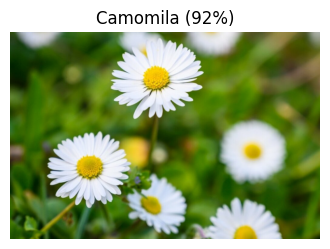

Plantas mais prováveis:
   Camomila                           91.9%
   Vinagreira (hibisco)               1.5%
   Espinheira-santa                   0.7%

🌿 Planta identificada: Camomila. Agora pode perguntar sobre ela!
   (Lembre: a IA pode errar. Confirme a identificação antes de usar qualquer planta.)

❓ Você [Camomila]: para que ela serve 
💬 Assistente: Camomila serve para queixas gastrintestinais leves, como distensão abdominal e espasmos leves (pág. 22). Além disso, ela auxilia no alívio de sintomas do resfriado comum e de afecções leves da pele, como queimaduras solares, feridas superficiais e furúnculos (pág. 22).
   📄 páginas consultadas: [22, 21, 38]

❓ Você [Camomila]: como eu preparo
💬 Assistente: Para preparar o chá de camomila, conforme indicado no documento, você deve seguir as instruções abaixo:

- Chá de camomila (ANVISA, fórmula 1): 0,5 a 4 g de inflorescências secas para 150 mL de água, por infusão durante 5 a 10 minutos.

Esta é a forma mais comum de preparar o chá 

Saving babosa-1-0aom3nptmt (1).jpg to babosa-1-0aom3nptmt (1).jpg


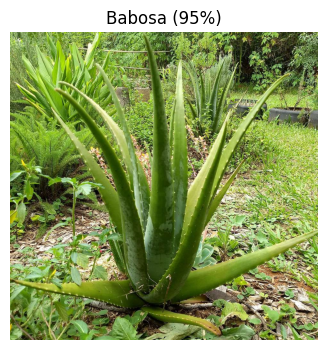

Plantas mais prováveis:
   Babosa                             94.5%
   Espinheira-santa                   0.6%
   Manjericão                         0.6%

🌿 Planta identificada: Babosa. Agora pode perguntar sobre ela!
   (Lembre: a IA pode errar. Confirme a identificação antes de usar qualquer planta.)

❓ Você [Babosa]: qual a cor dela
💬 Assistente: A cor da babosa é verde-acinzentada, conforme descrito na página 8 do documento.
   📄 páginas consultadas: [8, 10, 9]

❓ Você [Babosa]: pode comer?
💬 Assistente: Não encontrei essa informação no documento.
   📄 páginas consultadas: [9, 10, 8]

❓ Você [Babosa]: qual famlia ela e 
💬 Assistente: A babosa pertence à família Asphodelaceae (pág. 8).
   📄 páginas consultadas: [8, 3, 9]

❓ Você [Babosa]: o que mais posso perguntar 
💬 Assistente: Com base nos trechos fornecidos, você pode fazer várias perguntas relacionadas à babosa. Aqui estão algumas sugestões:

1. Como preparar e usar a babosa?
2. Quais são as principais contraindicações da babos

In [ ]:
# 12 · Chat 🌿
print(f"📚 Documento: {pdf_path}")
print("Comandos: 'foto' = enviar outra foto | 'limpar' = esquecer a planta | 'sair' = encerrar")
print("⚠️ Uso educativo: não substitui a orientação de profissionais de saúde.\n")

planta = identificar_planta()   # já abre o upload da foto no início

while True:
    pergunta = input(f"❓ Você{f' [{planta}]' if planta else ''}: ").strip()
    comando = pergunta.lower()
    if comando in ("sair", "exit", "quit"):
        print("👋 Encerrado."); break
    if comando in ("foto", "imagem"):
        planta = identificar_planta(); continue
    if comando == "limpar":
        planta = None
        print("🧹 Planta esquecida. Perguntas agora são sobre o guia em geral.\n"); continue
    if not pergunta:
        continue
    print("💬 Assistente: ", end="")
    responder_stream(f"(Planta identificada na foto: {planta}) {pergunta}" if planta else pergunta)
    print()

---
## 🛠️ Dicas e solução de problemas

| Situação | O que fazer |
|---|---|
| Erro ou lentidão no download das fotos | Rode a célula 3 de novo: ela continua de onde parou (fotos já baixadas são mantidas). |
| O Colab desconectou | Rode tudo de novo (Ambiente de execução → Executar tudo). |
| Erro de memória na GPU (`CUDA out of memory`) | Ambiente de execução → Reiniciar sessão e rodar as células em ordem, uma vez só. |
| A IA confundiu plantas parecidas (ex.: melissa × hortelã × manjericão) | É esperado: as folhas são parecidas. Veja o top 3 e tente uma foto mais próxima das folhas. |
| Foto de planta que não está entre as 14 | O modelo só conhece 14 plantas; se a confiança ficar abaixo de `LIMIAR_CONFIANCA`, ele avisa. |
| Quer mais acurácia | Aumente `FOTOS_POR_ESPECIE` (ex.: 500) e `EPOCAS` na célula 2 e rode novamente as células 3 a 7. |
| Resposta "não encontrei" para algo que está no PDF | Aumente `TOP_K_CHUNKS` ou `MAX_PAGINAS` na célula 2 e rode as células 2, 9 e 12. |

**Créditos das fotos:** as imagens do dataset são de usuários do iNaturalist, sob licenças CC0, CC BY e CC BY-NC. O arquivo `creditos.csv` lista o autor, a licença e o link de cada foto. Use o dataset apenas para fins educativos e não comerciais.